In [1]:
import re, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz

import time
from secedgar.cik_lookup import CIKLookup
import requests

import os
from pprint import pprint

In [ ]:
# this is the set of news that are currently or have been processed by the llm
news_final_set = pd.read_csv("data/filtered_news_with_keywords_v2.csv")
news_final_set

,og_index,Date,Article_title,Stock_symbol,Url,Article,MatchedKeyword,MatchScore
0,1,2021-10-19 00:00:00 UTC,"""9 Foolish Truths That I Hold to Be Self-Evident""",NVDA,https://www.nasdaq.com/articles/9-foolish-trut...,"If you're a longtime listener to this podcast,...",summit,100.0
1,3,2018-09-22 00:00:00 UTC,"""Alexa, Make Me Money"": Conversational AI Prep...",ORCL,https://www.nasdaq.com/articles/alexa-make-me-...,We've already gotten comfortable with digital ...,new legislation,100.0
2,5,2022-08-27 00:00:00 UTC,"""Ape"" Into AMC? Buy These Explosive Growth Sto...",BILL,https://www.nasdaq.com/articles/ape-into-amc-b...,"Some investors ""aped"" into AMC Entertainment (...",wildfire,100.0
3,6,2022-12-29 00:00:00 UTC,"""Avatar"" Sequel Crosses $1 Billion at the Box ...",DIS,https://www.nasdaq.com/articles/avatar-sequel-...,"In this video, I will talk about Walt Disney (...",avatar,100.0
4,7,2019-06-26 00:00:00 UTC,"""Avengers: Endgame"" Has Already Beaten Avatar'...",DIS,https://www.nasdaq.com/articles/avengers%3A-en...,"Almost since its record-setting debut, Avenger...",summit,100.0
...,...,...,...,...,...,...,...,...
82368,662371,2023-02-22 00:00:00 UTC,‘Worth a Roll of the Dice’: Ray Dalio’s Bridge...,SLB,https://www.nasdaq.com/articles/worth-a-roll-o...,"For many, competing in the Olympics is the pin...",olympics,100.0
82369,662381,2017-06-12 00:00:00 UTC,“Moonshots” Can Move Alphabet Inc (GOOGL) Stock,AMD,https://www.nasdaq.com/articles/moonshots-can-...,"InvestorPlace - Stock Market News, Stock Advic...",moon,100.0
82370,662384,2022-03-04 00:00:00 UTC,“Pixelmon” a Dud… And 4 Other Surprises This Week,XOM,https://www.nasdaq.com/articles/pixelmon-a-dud...,"InvestorPlace - Stock Market News, Stock Advic...",invasion,100.0
82371,662386,2021-09-15 00:00:00 UTC,“Yes in My Backyard”: How the Shift from China...,CC,https://www.nasdaq.com/articles/yes-in-my-back...,"InvestorPlace - Stock Market News, Stock Advic...",missile,100.0


In [ ]:
# run this to check the index in the original set
news_final_set.iloc[23214]

og_index                                                     155920
Date                                        2023-04-26 00:00:00 UTC
Article_title     Cloud, not consoles, blocks Microsoft's Activi...
Stock_symbol                                                   NVDA
Url               https://www.nasdaq.com/articles/cloud-not-cons...
Article           By Paul Sandle\nLONDON, April 26 (Reuters) - F...
MatchedKeyword                                               brexit
MatchScore                                                    100.0
Name: 23214, dtype: object

So we have a total of 82,373 news to be processed.

## How many news have we processed so far? How many spotted events?

In [105]:
# first open the jsonfiles and put them into the same list of events, we have different experiments
df_events_1 = pd.read_json("output/experiment_2025-08-02_00-39-35.jsonl", lines=True)
df_events_2 = pd.read_json("output/experiment_2025-08-18_17-12-24.jsonl", lines=True)
df_events_3 = pd.read_json("output/experiment_2025-08-23_17-56-01.jsonl", lines=True) 
df_events_4 = pd.read_json("output/experiment_2025-09-12_16-18-58.jsonl", lines = True)

df_events = pd.concat([df_events_1, df_events_2,df_events_3,df_events_4], ignore_index=True)
df_events

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
0,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2600,18.29
1,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2568,19.96
2,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2547,16.18
3,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2489,14.65
4,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2515,20.25
...,...,...,...,...,...,...
350268,27170,\n Date:2020-02-28 00:00:00 UTC\n Title:...,This is a list of events that took part in the...,[],1051,4.35
350269,27170,\n Date:2020-02-28 00:00:00 UTC\n Title:...,This is a list of events that took part in the...,[ ],1065,4.42
350270,27170,\n Date:2020-02-28 00:00:00 UTC\n Title:...,This is a list of events that took part in the...,[],1231,4.87
350271,27170,\n Date:2020-02-28 00:00:00 UTC\n Title:...,This is a list of events that took part in the...,"[{\n ""event_id"": ""2020_40"",\n ""event_tex...",875,13.00


In [ ]:
# I am not using this code because it does not read the files in the same order, but it is useful if we have many files

# output_folder = "output"
# df_events = pd.DataFrame()

# for result_json in os.listdir("output"):
#     print(result_json)
#     df_events_new = pd.read_json(f"{output_folder}/{result_json}", lines=True)
#     df_events = pd.concat([df_events, df_events_new], ignore_index=True)

# df_events

For checking the spotted events we first have to do a little bit of cleaning.

In [107]:
# remove the white spaces in the responses and prompts
df_events["response"] = df_events["response"].str.strip()
df_events["user_prompt"] = df_events["user_prompt"].str.strip()
df_events["system_prompt"] = df_events["system_prompt"].str.strip()
df_events

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
0,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2600,18.29
1,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2568,19.96
2,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2547,16.18
3,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2489,14.65
4,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2515,20.25
...,...,...,...,...,...,...
350268,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[],1051,4.35
350269,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[ ],1065,4.42
350270,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[],1231,4.87
350271,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"[{\n ""event_id"": ""2020_40"",\n ""event_tex...",875,13.00


In [108]:
# extracting the list of events from llm response

def extract_event_json(raw_response):    
    match = re.search(r"\[.*\]", raw_response, re.S) 
    if match:
        try:
            data = json.loads(match.group(0))
            return data
        except Exception:
            # Replace Python None with JSON null
            fixed = re.sub(r"\bNone\b", "null", match.group(0))
            try:
                data = json.loads(fixed)
                return data
            except Exception:
                # If still fails, return empty list
                return []
    # If no match, return empty list
    return []

df_events["response"] = df_events["response"].apply(extract_event_json)
df_events

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
0,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2600,18.29
1,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2568,19.96
2,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2547,16.18
3,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2489,14.65
4,0,"Date:2021-10-19 00:00:00 UTC Title:""9 Foolish ...",This is a list of events that took part in the...,[],2515,20.25
...,...,...,...,...,...,...
350268,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[],1051,4.35
350269,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[],1065,4.42
350270,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,[],1231,4.87
350271,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"[{'event_id': '2020_40', 'event_text': 'The CO...",875,13.00


In [109]:
# long term it is better if we work with a single record per event instead of a full list
df_events = df_events.explode("response").dropna() # also remove nan (result from empty lists)
df_events

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
16,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event_text': '', 'confidence...",2547,12.32
17,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event_text': '', 'confidence...",2489,12.79
18,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event_text': '', 'confidence...",2515,12.43
20,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event_text': '', 'confidence...",2571,17.18
20,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event_text': '', 'confidence...",2571,17.18
...,...,...,...,...,...,...
350267,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"{'event_id': None, 'event_text': None, 'confid...",1000,8.34
350271,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"{'event_id': '2020_40', 'event_text': 'The COV...",875,13.00
350271,27170,Date:2020-02-28 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"{'event_id': '2020_41', 'event_text': 'Fears o...",875,13.00
350272,27171,Date:2020-03-27 00:00:00 UTC\n Title:Dow Fa...,This is a list of events that took part in the...,"{'event_id': '2001_6', 'event_text': 'Nineteen...",1072,22.52


There are many hallucinations and events spotted with a low confidence, from now lets just focus in events with a high confidence and lets remove the hallucinations. We decided we will use the 0.9 threshold since it is more strict and accurate. We can be more sure that the event correctly reflects the content of the news.

In [ ]:
# 1. Remove events with low confidence score

def make_float(num): # this is a funciton to handle float transforming when we have other types of data such as empty strings
    try:
        return float(num)
    except ValueError:
        return 0

CONFIDENCE_THRESHOLD = 0.9 # modify this threshold as needed, lower confidence_thresholds yield more events but also more noise,
                            # higher thresholds yield less events but more precise results

def has_high_confidence(event, threshold=CONFIDENCE_THRESHOLD): # increase the threshold
    return isinstance(event, dict) and event.get("confidence", 0) is not None and make_float(event.get("confidence", 0)) >= threshold

high_confidence = df_events[df_events["response"].apply(has_high_confidence)]
high_confidence

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
22,1,"Date:2018-09-22 00:00:00 UTC Title:""Alexa, Mak...",This is a list of events that took part in the...,"{'event_id': '', 'event': 'Conversational AI p...",2594,14.97
81,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...",This is a list of events that took part in the...,"{'event_id': '2009_0', 'event_text': 'The cryp...",1643,9.98
127,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2021_37', 'event_text': 'Kabul f...",1408,20.26
128,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2022_5', 'event_text': 'Russia i...",1186,12.79
291,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...",This is a list of events that took part in the...,"{'event_id': '2020_5', 'event_text': 'Bong Joo...",1076,10.89
...,...,...,...,...,...,...
350030,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,This is a list of events that took part in the...,"{'event_id': '2019_5', 'event_text': 'A major ...",807,6.17
350043,27144,Date:2012-06-25 00:00:00 UTC\n Title:Dow De...,This is a list of events that took part in the...,"{'event_id': 'None', 'event_text': 'Euro-zone ...",1263,17.10
350143,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",915,7.65
350216,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",1139,12.33


In [111]:
# 2. from the high confidence events we should remove the hallucinations, removing the events that do not have an id or the id is invented
# run this to observe hallucinations manually
for response in high_confidence["response"]:
    print(response)

{'event_id': '', 'event': 'Conversational AI prepares for the enterprise', 'confidence': 0.9}
{'event_id': '2009_0', 'event_text': 'The cryptocurrency Bitcoin is launched.', 'confidence': 0.9}
{'event_id': '2021_37', 'event_text': 'Kabul falls following the 2021 Taliban offensive, as the Islamic Republic of Afghanistan collapses, and the country is governed thereafter by the Taliban as the reinstated Islamic Emirate of Afghanistan. The War in Afghanistan thus ends after 20 years following the withdrawal of U.S. and coalition troops.', 'confidence': 0.9}
{'event_id': '2022_5', 'event_text': 'Russia invades Ukraine, escalating the Russo-Ukrainian War, causing a refugee crisis and tens of thousands of deaths on both sides.', 'confidence': 0.9}
{'event_id': '2020_5', 'event_text': "Bong Joon-ho's Parasite becomes the first South Korean film to receive Academy Award recognitions at the 92nd Academy Awards.", 'confidence': 1}
{'event_id': '2009_4', 'event_text': 'Avatar is released in cinema

Are the events accurate enough or do we need to increase the 0.9 threshold?? We will analyze a small sample.

In [112]:
sample = high_confidence.iloc[9]
pprint(sample.response)
pprint(sample.user_prompt)

{'confidence': 0.9, 'event_id': '', 'event_text': ''}
('Date:2020-06-02 00:00:00 UTC\n'
 '    Title:#BlackOutTuesday sweeps social media as U.S. street protests '
 'escalate\n'
 '    Text:Recasts; adds Twitter trends, comments\n'
 'June 2 (Reuters) - The hashtag #BlackOutTuesday became the top trending item '
 'on Twitter as hundreds of thousands of businesses and individuals, including '
 'TV channels and celebrities, posted black screen shots to signal support for '
 'racial justice as street protests over the police killing of George Floyd '
 'entered a second week.\n'
 'Many companies paused normal work and directed their efforts to support the '
 'work of Black Lives Matter and other social justice groups.\n'
 'Streaming service Spotify highlighted the music of black artists, Sirius XM '
 'Radio said it would silence its music channels for three minutes, and Apple '
 "Music DJ Zane Lowe tweeted that he wouldn't host his radio show but would be "
 '"listening, learning and looking 

We analyzed and read a small sample of news articles to check whether the LLM’s output is coherent and accurate. We observed that, in many cases, events with a confidence score of 0.9 are somewhat accurate, since they are loosely related to the article. For example, see cases 9 to 11, about the news on George Floyd’s death: the event “Spotify is launched” (because the article mentions African American artists on Spotify) and another event associated with the death of a different Black public figure—who is not actually mentioned in the article—both receive 0.9 confidence. Meanwhile, the event directly linked to George Floyd’s death is assigned 100% confidence.

In [113]:
# Step 1: Normalize the response column to dicts (or NaN)
high_confidence["response"] = high_confidence["response"].apply(
    lambda x: {
        "event_id": x.get("event_id") if isinstance(x, dict) else None,
        "event_text": x.get("event_text") if isinstance(x, dict) else None
    } if isinstance(x, dict) else np.nan
)

# Step 2: Drop rows where response is NaN
high_confidence = high_confidence.dropna(subset=["response"])

# Step 3: Filter by event_id not empty/None
high_confidence = high_confidence[
    high_confidence["response"].apply(lambda x: x.get("event_id") not in [None, "", "None"])
]

# Step 4: Filter by event_text not empty/None
high_confidence = high_confidence[
    high_confidence["response"].apply(lambda x: x.get("event_text") not in [None, "", "None"])
]

# Step 5: Remove events with fake ids: event_id should match pattern '2\d{3}_\d+'
high_confidence = high_confidence[
    high_confidence["response"].apply(
        lambda x: bool(re.match(r"^2\d{3}_\d+$", x.get("event_id")))
    )
]

/tmp/ipykernel_76362/3191923313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_confidence["response"] = high_confidence["response"].apply(


In [114]:
high_confidence["response"].value_counts()

response
{'event_id': '2022_39', 'event_text': 'OpenAI launches ChatGPT, an AI chatbot.'}                                                                                                                       336
{'event_id': '2022_5', 'event_text': 'Russia invades Ukraine, escalating the Russo-Ukrainian War, causing a refugee crisis and tens of thousands of deaths on both sides.'}                            324
{'event_id': '2009_0', 'event_text': 'The cryptocurrency Bitcoin is launched.'}                                                                                                                        225
{'event_id': '2016_11', 'event_text': 'Donald Trump wins the 2016 presidential election, in an upset against Hillary Clinton, the first female to be nominated for a major party.'}                    174
{'event_id': '2014_0', 'event_text': 'Euromaidan protest in Ukraine sparks a revolution and the overthrow of Viktor Yanukovych, leading to Russia's annexation of Crimea and the wa

Finally, there are some cases in which the id is in a correct format but it does not correspond to this event. In such cases we should remove the example as well.

In [115]:
# check the detected event with the original event in the list, if the text is very different then there is an hallucination

with open("data/new_events_with_ids.json") as f:
    original_events = json.load(f)

def check_with_original_event(event, threshold=85):
    original_event = next((e for e in original_events if e.get("event_id") == event["event_id"]), None)
    
    #print(f"\nDetected event with id: {event['event_id']}: {event['event_text']}")
    
    if not original_event:
        #print("Original event not found.")
        return False
    
    #print(f"Original event with id: {original_event['event_id']}: {original_event['text']}")
    event_text = event["event_text"].lower()
    original_text = original_event["text"].lower()
    
    similarity = fuzz.partial_ratio(event_text, original_text)
    #print(similarity)
    
    return similarity >= threshold # basically, we only keep the events if they are the same, we use fuzzy search in case the llm changes some of the text or withdraws part of it

event = {'event_id': '2003_0', 'event_text': 'COVID-19 pandemic begins'} 
event = {'event_id': '2017_0', 'event_text': 'Trump administration provides formal backing to a draft bill introduced by House Republicans which aims to repeal and replace the Obamacare healthcare law.'}

# check_with_original_event(event)

high_confidence = high_confidence[high_confidence["response"].apply(check_with_original_event)]
high_confidence

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
81,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...",This is a list of events that took part in the...,"{'event_id': '2009_0', 'event_text': 'The cryp...",1643,9.98
127,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2021_37', 'event_text': 'Kabul f...",1408,20.26
128,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2022_5', 'event_text': 'Russia i...",1186,12.79
291,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...",This is a list of events that took part in the...,"{'event_id': '2020_5', 'event_text': 'Bong Joo...",1076,10.89
405,29,"Date:2016-01-08 00:00:00 UTC\n Title:""Star ...",This is a list of events that took part in the...,"{'event_id': '2009_4', 'event_text': 'Avatar i...",1430,10.92
...,...,...,...,...,...,...
349911,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,This is a list of events that took part in the...,"{'event_id': '2017_0', 'event_text': 'Donald T...",1675,8.32
350030,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,This is a list of events that took part in the...,"{'event_id': '2019_5', 'event_text': 'A major ...",807,6.17
350143,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",915,7.65
350216,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",1139,12.33


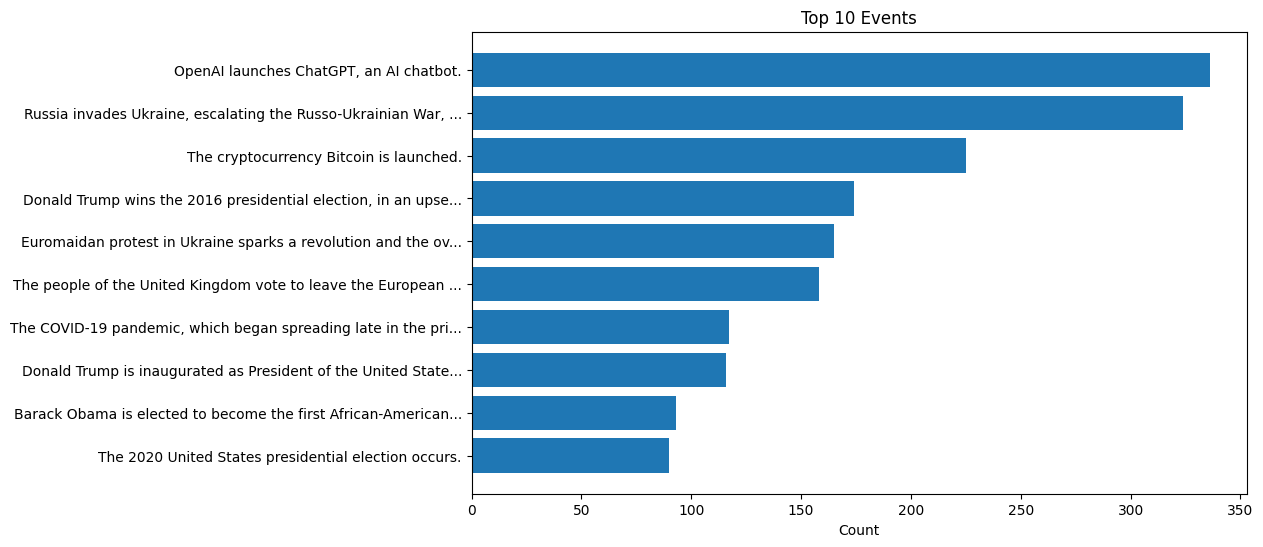

In [116]:
# Get event_texts from filtered_events
event_texts = high_confidence["response"].apply(lambda x: x.get("event_text") if isinstance(x, dict) else None)

# Count occurrences of each event_text
event_counts = event_texts.value_counts().head(10)

short_event_texts = [text[:60] + "..." if len(text) > 60 else text for text in event_counts.index]
counts = event_counts.values

plt.figure(figsize=(10, 6))
plt.barh(short_event_texts, counts)
plt.xlabel("Count")
plt.title("Top 10 Events")
plt.gca().invert_yaxis()
plt.show()

In [117]:
# how many news potentially spotted events
high_confidence["user_prompt"].drop_duplicates()

81        Date:2017-12-07 00:00:00 UTC\n    Title:"Bitco...
127       Date:2022-03-24 00:00:00 UTC\n    Title:"Chip ...
291       Date:2020-02-10 00:00:00 UTC\n    Title:"Paras...
405       Date:2016-01-08 00:00:00 UTC\n    Title:"Star ...
429       Date:2023-08-05 00:00:00 UTC Title:"The Ride o...
                                ...                        
349910    Date:2017-02-28 00:00:00 UTC\n    Title:Dow CE...
350030    Date:2019-04-16 00:00:00 UTC\n    Title:Dow Cl...
350143    Date:2017-04-18 00:00:00 UTC\n    Title:Dow ET...
350216    Date:2018-12-12 00:00:00 UTC\n    Title:Dow En...
350271    Date:2020-02-28 00:00:00 UTC\n    Title:Dow Fa...
Name: user_prompt, Length: 2440, dtype: object

In [118]:
high_confidence

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
81,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...",This is a list of events that took part in the...,"{'event_id': '2009_0', 'event_text': 'The cryp...",1643,9.98
127,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2021_37', 'event_text': 'Kabul f...",1408,20.26
128,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2022_5', 'event_text': 'Russia i...",1186,12.79
291,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...",This is a list of events that took part in the...,"{'event_id': '2020_5', 'event_text': 'Bong Joo...",1076,10.89
405,29,"Date:2016-01-08 00:00:00 UTC\n Title:""Star ...",This is a list of events that took part in the...,"{'event_id': '2009_4', 'event_text': 'Avatar i...",1430,10.92
...,...,...,...,...,...,...
349911,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,This is a list of events that took part in the...,"{'event_id': '2017_0', 'event_text': 'Donald T...",1675,8.32
350030,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,This is a list of events that took part in the...,"{'event_id': '2019_5', 'event_text': 'A major ...",807,6.17
350143,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",915,7.65
350216,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",1139,12.33


In [119]:
high_confidence["response"].drop_duplicates()

81        {'event_id': '2009_0', 'event_text': 'The cryp...
127       {'event_id': '2021_37', 'event_text': 'Kabul f...
128       {'event_id': '2022_5', 'event_text': 'Russia i...
291       {'event_id': '2020_5', 'event_text': 'Bong Joo...
405       {'event_id': '2009_4', 'event_text': 'Avatar i...
                                ...                        
324749    {'event_id': '2021_15', 'event_text': 'Bucking...
331802    {'event_id': '2023_0', 'event_text': '2023 Isr...
333385    {'event_id': '2001_12', 'event_text': 'During ...
335773    {'event_id': '2012_9', 'event_text': 'Sandy Ho...
350030    {'event_id': '2019_5', 'event_text': 'A major ...
Name: response, Length: 173, dtype: object

## Linking the spotted event to the companies

In [ ]:
# first we need to get the news from the original set (the one that contains all the companies linked to each news)
original_news = pd.read_csv("data/filtered_news_only_SP.csv")
original_news

,Date,Article_title,Stock_symbol,Url,Article
0,2023-12-16 23:00:00 UTC,Interesting A Put And Call Options For August ...,A,https://www.nasdaq.com/articles/interesting-a-...,"Investors in Agilent Technologies, Inc. (Symbo..."
1,2023-12-12 00:00:00 UTC,Wolfe Research Initiates Coverage of Agilent T...,A,https://www.nasdaq.com/articles/wolfe-research...,"Fintel reports that on December 13, 2023, Wolf..."
2,2023-12-12 00:00:00 UTC,Agilent Technologies Reaches Analyst Target Price,A,https://www.nasdaq.com/articles/agilent-techno...,"In recent trading, shares of Agilent Technolog..."
3,2023-12-07 00:00:00 UTC,Agilent (A) Enhances BioTek Cytation C10 With ...,A,https://www.nasdaq.com/articles/agilent-a-enha...,Agilent Technologies A is enhancing its BioTek...
4,2023-12-07 00:00:00 UTC,"Pre-Market Most Active for Dec 7, 2023 : SQQQ,...",A,https://www.nasdaq.com/articles/pre-market-mos...,The NASDAQ 100 Pre-Market Indicator is up 70.2...
...,...,...,...,...,...
1068197,2013-02-04 00:00:00 UTC,Zoetis Commences Trading - Analyst Blog,ZTS,https://www.nasdaq.com/articles/zoetis-commenc...,"Zoetis Inc. ( ZTS ), the former Animal Health ..."
1068198,2013-02-01 00:00:00 UTC,Weekly recap: Most January pricings since 2006...,ZTS,https://www.nasdaq.com/articles/weekly-recap-m...,"After last week's five deals, January finished..."
1068199,2013-01-31 00:00:00 UTC,Pfizer's animal health unit Zoetis prices IPO ...,ZTS,https://www.nasdaq.com/articles/pfizers-animal...,"Zoetis, a spin-off of Pfizer's global animal h..."
1068200,2013-01-28 00:00:00 UTC,5 US IPOs planned for the week of Jan 28,ZTS,https://www.nasdaq.com/articles/5-us-ipos-plan...,The following IPOs are expected to price this ...


In [127]:
# we are only interested in a unique identifier and the company tickers
# original_news = original_news[["Url","Stock_symbol"]] # maybe url and ticker symbol ?
original_news[["Url","Stock_symbol"]].sort_values("Url").head(20)

,Url,Stock_symbol
525020,https://www.nasdaq.com/articles/%241-billion-s...,GS
767264,https://www.nasdaq.com/articles/%241-billion-s...,PEG
720955,https://www.nasdaq.com/articles/%241-trillion-...,NVDA
583875,https://www.nasdaq.com/articles/%241.2-billion...,KIM
34866,https://www.nasdaq.com/articles/%241.2-billion...,ACI
1037989,https://www.nasdaq.com/articles/%241.2-trillio...,WMT
650985,https://www.nasdaq.com/articles/%241.2-trillio...,MSFT
49693,https://www.nasdaq.com/articles/%241.5-billion...,ADNT
565801,https://www.nasdaq.com/articles/%241.6-billion...,IAC
575340,https://www.nasdaq.com/articles/%2410-billion-...,INTC


In [128]:
# second we need the dataset that contains an identifier of the news (so that we can later link to the original company) and the corresponding event
news_final_set = pd.read_csv("data/filtered_news_with_keywords_v2.csv")
news_final_set

,og_index,Date,Article_title,Stock_symbol,Url,Article,MatchedKeyword,MatchScore
0,1,2021-10-19 00:00:00 UTC,"""9 Foolish Truths That I Hold to Be Self-Evident""",NVDA,https://www.nasdaq.com/articles/9-foolish-trut...,"If you're a longtime listener to this podcast,...",summit,100.0
1,3,2018-09-22 00:00:00 UTC,"""Alexa, Make Me Money"": Conversational AI Prep...",ORCL,https://www.nasdaq.com/articles/alexa-make-me-...,We've already gotten comfortable with digital ...,new legislation,100.0
2,5,2022-08-27 00:00:00 UTC,"""Ape"" Into AMC? Buy These Explosive Growth Sto...",BILL,https://www.nasdaq.com/articles/ape-into-amc-b...,"Some investors ""aped"" into AMC Entertainment (...",wildfire,100.0
3,6,2022-12-29 00:00:00 UTC,"""Avatar"" Sequel Crosses $1 Billion at the Box ...",DIS,https://www.nasdaq.com/articles/avatar-sequel-...,"In this video, I will talk about Walt Disney (...",avatar,100.0
4,7,2019-06-26 00:00:00 UTC,"""Avengers: Endgame"" Has Already Beaten Avatar'...",DIS,https://www.nasdaq.com/articles/avengers%3A-en...,"Almost since its record-setting debut, Avenger...",summit,100.0
...,...,...,...,...,...,...,...,...
82368,662371,2023-02-22 00:00:00 UTC,‘Worth a Roll of the Dice’: Ray Dalio’s Bridge...,SLB,https://www.nasdaq.com/articles/worth-a-roll-o...,"For many, competing in the Olympics is the pin...",olympics,100.0
82369,662381,2017-06-12 00:00:00 UTC,“Moonshots” Can Move Alphabet Inc (GOOGL) Stock,AMD,https://www.nasdaq.com/articles/moonshots-can-...,"InvestorPlace - Stock Market News, Stock Advic...",moon,100.0
82370,662384,2022-03-04 00:00:00 UTC,“Pixelmon” a Dud… And 4 Other Surprises This Week,XOM,https://www.nasdaq.com/articles/pixelmon-a-dud...,"InvestorPlace - Stock Market News, Stock Advic...",invasion,100.0
82371,662386,2021-09-15 00:00:00 UTC,“Yes in My Backyard”: How the Shift from China...,CC,https://www.nasdaq.com/articles/yes-in-my-back...,"InvestorPlace - Stock Market News, Stock Advic...",missile,100.0


In [129]:
# and the dataste with the clean events
high_confidence

,news_id,user_prompt,system_prompt,response,total_tokens,inference_time
81,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...",This is a list of events that took part in the...,"{'event_id': '2009_0', 'event_text': 'The cryp...",1643,9.98
127,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2021_37', 'event_text': 'Kabul f...",1408,20.26
128,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...",This is a list of events that took part in the...,"{'event_id': '2022_5', 'event_text': 'Russia i...",1186,12.79
291,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...",This is a list of events that took part in the...,"{'event_id': '2020_5', 'event_text': 'Bong Joo...",1076,10.89
405,29,"Date:2016-01-08 00:00:00 UTC\n Title:""Star ...",This is a list of events that took part in the...,"{'event_id': '2009_4', 'event_text': 'Avatar i...",1430,10.92
...,...,...,...,...,...,...
349911,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,This is a list of events that took part in the...,"{'event_id': '2017_0', 'event_text': 'Donald T...",1675,8.32
350030,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,This is a list of events that took part in the...,"{'event_id': '2019_5', 'event_text': 'A major ...",807,6.17
350143,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",915,7.65
350216,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,This is a list of events that took part in the...,"{'event_id': '2016_7', 'event_text': 'The peop...",1139,12.33


In [130]:
# create the dataframe that contains the events and the news url
df_events_merged = pd.merge(high_confidence,news_final_set,left_on="news_id",right_index=True)
# keep only the essential rows maybe
df_events_merged = df_events_merged[["news_id","user_prompt","response","Url"]]

df_events_merged.sort_values("news_id")

,news_id,user_prompt,response,Url
81,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...
127,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2021_37', 'event_text': 'Kabul f...",https://www.nasdaq.com/articles/chip-rally-nat...
128,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2022_5', 'event_text': 'Russia i...",https://www.nasdaq.com/articles/chip-rally-nat...
291,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...","{'event_id': '2020_5', 'event_text': 'Bong Joo...",https://www.nasdaq.com/articles/parasite-domin...
405,29,"Date:2016-01-08 00:00:00 UTC\n Title:""Star ...","{'event_id': '2009_4', 'event_text': 'Avatar i...",https://www.nasdaq.com/articles/star-wars-forc...
...,...,...,...,...
349911,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,"{'event_id': '2017_0', 'event_text': 'Donald T...",https://www.nasdaq.com/articles/dow-ceos-make-...
350030,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,"{'event_id': '2019_5', 'event_text': 'A major ...",https://www.nasdaq.com/articles/dow-closes-hig...
350143,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-etf-falls-...
350216,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-enjoys-str...


Now we merge the events dataframe to the original dataframe, in which we want to look for the companies linking throught the news url

In [131]:
df_all = pd.merge(df_events_merged,original_news,on="Url")
df_all.sort_values("news_id")

,news_id,user_prompt,response,Url,Date,Article_title,Stock_symbol,Article
0,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CBOE,"The price of bitcoin, the oldest and largest c..."
1,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CME,"The price of bitcoin, the oldest and largest c..."
2,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2021_37', 'event_text': 'Kabul f...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...
3,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2022_5', 'event_text': 'Russia i...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...
4,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...","{'event_id': '2020_5', 'event_text': 'Bong Joo...",https://www.nasdaq.com/articles/parasite-domin...,2020-02-10 00:00:00 UTC,"""Parasite"" Dominated the 2019 Oscars",CMCSA,The results are in for the Academy Awards of 2...
...,...,...,...,...,...,...,...,...
4757,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,"{'event_id': '2017_0', 'event_text': 'Donald T...",https://www.nasdaq.com/articles/dow-ceos-make-...,2017-02-28 00:00:00 UTC,Dow CEOs Make Millions: 2 Financial Blue Chips...,GS,The CEOs of most of the companies in the Dow J...
4758,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,"{'event_id': '2019_5', 'event_text': 'A major ...",https://www.nasdaq.com/articles/dow-closes-hig...,2019-04-16 00:00:00 UTC,Dow Closes Higher on Big Boeing Finish,BA,"Stocks finished the day higher, with the Dow s..."
4759,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-etf-falls-...,2017-04-18 00:00:00 UTC,Dow ETF Falls On A Big Earnings Day For Blue-C...,GS,Exchange traded funds tracking major stock ind...
4760,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-enjoys-str...,2018-12-12 00:00:00 UTC,Dow Enjoys Strong Day Amid China Trade Optimism,CMCSA,"Wall Street enjoyed a positive session, as the..."


In [132]:
df_all["response"].drop_duplicates()

0       {'event_id': '2009_0', 'event_text': 'The cryp...
2       {'event_id': '2021_37', 'event_text': 'Kabul f...
3       {'event_id': '2022_5', 'event_text': 'Russia i...
4       {'event_id': '2020_5', 'event_text': 'Bong Joo...
6       {'event_id': '2009_4', 'event_text': 'Avatar i...
                              ...                        
4339    {'event_id': '2021_15', 'event_text': 'Bucking...
4499    {'event_id': '2023_0', 'event_text': '2023 Isr...
4524    {'event_id': '2001_12', 'event_text': 'During ...
4555    {'event_id': '2012_9', 'event_text': 'Sandy Ho...
4758    {'event_id': '2019_5', 'event_text': 'A major ...
Name: response, Length: 173, dtype: object

In [133]:
stock_counts = original_news.groupby('Url')['Stock_symbol'].agg(list).reset_index()
stock_counts["n stocks"] = stock_counts["Stock_symbol"].apply(len)
stock_counts

,Url,Stock_symbol,n stocks
0,https://www.nasdaq.com/articles/%241-billion-s...,"[GS, PEG]",2
1,https://www.nasdaq.com/articles/%241-trillion-...,[NVDA],1
2,https://www.nasdaq.com/articles/%241.2-billion...,"[ACI, KIM]",2
3,https://www.nasdaq.com/articles/%241.2-trillio...,"[MSFT, WMT]",2
4,https://www.nasdaq.com/articles/%241.5-billion...,[ADNT],1
...,...,...,...
752726,https://www.nasdaq.com/articles/zyngas-q4-loss...,[EA],1
752727,https://www.nasdaq.com/articles/zyngas-znga-hi...,[TTWO],1
752728,https://www.nasdaq.com/articles/zyprexa-pulls-...,[ALKS],1
752729,https://www.nasdaq.com/articles/zyxi-q2-2012-f...,[CMS],1


In [134]:
stock_counts.describe()

,n stocks
count,752731.000000
mean,1.419102
std,0.839432
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,44.000000


array([[<Axes: title={'center': 'n stocks'}>]], dtype=object)

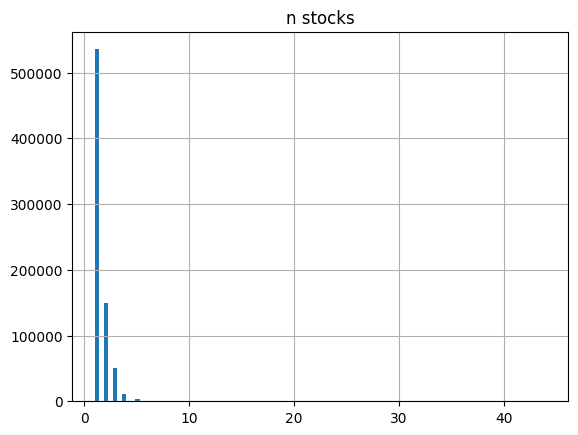

In [135]:
stock_counts.hist(bins=100)

In [136]:
df_all["Stock_symbol"].value_counts()#.sum()

Stock_symbol
MSFT    227
NVDA    156
GS      122
TSLA    112
CVX     107
       ... 
MEDP      1
LEN       1
INSW      1
SON       1
GEF       1
Name: count, Length: 560, dtype: int64

326 from the total 1500 aprox companies that we have in FinKG appear here.

Lastly lets create the triple file for FinKG. We will need:
1. The CIK codes for each company, which we can obtain using EDGAR.
2. The event ids.

The triples csv will folow this structure:
Event, IMPACTS, Company
(event_id, IMPACTS, company CIK)

### Company CIK

In [137]:
user_agent="Rocio Jimenez (rjvillen@gmail.com)"
headers = {'user-agent': user_agent}

r = requests.get('https://www.sec.gov/files/company_tickers.json', headers=headers)

with open('company_tickers.json', 'w') as f:
    f.write(r.text)

In [138]:
with open('company_tickers.json') as f:
    cik_json = json.load(f)

ticker_to_cik = {v['ticker']: str(v['cik_str']).zfill(10) for v in cik_json.values()}
ticker_to_cik

{'NVDA': '0001045810',
 'MSFT': '0000789019',
 'AAPL': '0000320193',
 'GOOGL': '0001652044',
 'AMZN': '0001018724',
 'META': '0001326801',
 'AVGO': '0001730168',
 'BRK-B': '0001067983',
 'TSLA': '0001318605',
 'ORCL': '0001341439',
 'JPM': '0000019617',
 'WMT': '0000104169',
 'V': '0001403161',
 'LLY': '0000059478',
 'SPY': '0000884394',
 'MA': '0001141391',
 'NFLX': '0001065280',
 'XOM': '0000034088',
 'JNJ': '0000200406',
 'COST': '0000909832',
 'HD': '0000354950',
 'PLTR': '0001321655',
 'ABBV': '0001551152',
 'BABA': '0001577552',
 'BAC': '0000070858',
 'PG': '0000080424',
 'ASML': '0000937966',
 'CVX': '0000093410',
 'SAP': '0001000184',
 'GE': '0000040545',
 'KO': '0000021344',
 'TMUS': '0001283699',
 'UNH': '0000731766',
 'CSCO': '0000858877',
 'PM': '0001413329',
 'WFC': '0000072971',
 'AMD': '0000002488',
 'AZN': '0000901832',
 'TM': '0001094517',
 'MS': '0000895421',
 'NVS': '0001114448',
 'NVO': '0000353278',
 'IBM': '0000051143',
 'HSBC': '0001089113',
 'GS': '0000886982',


In [139]:
def map_ticker_cik(ticker):
    cik = ticker_to_cik.get(ticker)
    if not ticker:
        raise ValueError(f"Could not find cik for {ticker}")
    return cik

df_all["CIK"] = df_all["Stock_symbol"].apply(map_ticker_cik)
df_all["CIK"].value_counts()#.sum()

CIK
0000789019    227
0001045810    156
0000886982    122
0001318605    112
0000093410    107
             ... 
0000810136      1
0001004434      1
0001627223      1
0000064996      1
0000109198      1
Name: count, Length: 549, dtype: int64

In [ ]:
inverse_mapped = df_all.groupby("CIK")['Stock_symbol'].agg((set)).reset_index()
inverse_mapped["len"] = inverse_mapped.Stock_symbol.apply(len)
inverse_mapped[inverse_mapped["len"]>1]
# tiene sentido el resultado porque hay algunos tickers que mappean al mismo cik

,CIK,Stock_symbol,len
426,0001336917,"{UA, UAA}",2


In [141]:
df_all["event_id"] = df_all["response"].apply(lambda x: x["event_id"])
df_all

,news_id,user_prompt,response,Url,Date,Article_title,Stock_symbol,Article,CIK,event_id
0,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CBOE,"The price of bitcoin, the oldest and largest c...",0001374310,2009_0
1,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CME,"The price of bitcoin, the oldest and largest c...",0001156375,2009_0
2,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2021_37', 'event_text': 'Kabul f...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...,0001045810,2021_37
3,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2022_5', 'event_text': 'Russia i...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...,0001045810,2022_5
4,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...","{'event_id': '2020_5', 'event_text': 'Bong Joo...",https://www.nasdaq.com/articles/parasite-domin...,2020-02-10 00:00:00 UTC,"""Parasite"" Dominated the 2019 Oscars",CMCSA,The results are in for the Academy Awards of 2...,0001166691,2020_5
...,...,...,...,...,...,...,...,...,...,...
4757,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,"{'event_id': '2017_0', 'event_text': 'Donald T...",https://www.nasdaq.com/articles/dow-ceos-make-...,2017-02-28 00:00:00 UTC,Dow CEOs Make Millions: 2 Financial Blue Chips...,GS,The CEOs of most of the companies in the Dow J...,0000886982,2017_0
4758,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,"{'event_id': '2019_5', 'event_text': 'A major ...",https://www.nasdaq.com/articles/dow-closes-hig...,2019-04-16 00:00:00 UTC,Dow Closes Higher on Big Boeing Finish,BA,"Stocks finished the day higher, with the Dow s...",0000012927,2019_5
4759,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-etf-falls-...,2017-04-18 00:00:00 UTC,Dow ETF Falls On A Big Earnings Day For Blue-C...,GS,Exchange traded funds tracking major stock ind...,0000886982,2016_7
4760,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-enjoys-str...,2018-12-12 00:00:00 UTC,Dow Enjoys Strong Day Amid China Trade Optimism,CMCSA,"Wall Street enjoyed a positive session, as the...",0001166691,2016_7


In [142]:
df_all["event_id"].drop_duplicates()

0        2009_0
2       2021_37
3        2022_5
4        2020_5
6        2009_4
         ...   
4295     2011_6
4339    2021_15
4499     2023_0
4555     2012_9
4758     2019_5
Name: event_id, Length: 160, dtype: object

In [143]:
triples = df_all[["CIK","event_id"]].rename(columns={"CIK":"Company","event_id":"Event"})
triples["IMPACTS"] = "IMPACTS"
triples = triples[["Event","IMPACTS","Company"]]
triples

,Event,IMPACTS,Company
0,2009_0,IMPACTS,0001374310
1,2009_0,IMPACTS,0001156375
2,2021_37,IMPACTS,0001045810
3,2022_5,IMPACTS,0001045810
4,2020_5,IMPACTS,0001166691
...,...,...,...
4757,2017_0,IMPACTS,0000886982
4758,2019_5,IMPACTS,0000012927
4759,2016_7,IMPACTS,0000886982
4760,2016_7,IMPACTS,0001166691


In [144]:
# triples.to_csv("IMPACTS.csv",index=None)

There are some duplicates, which means there are more than one news that says that an specific event impacts a company. Maybe this is important to reflect the importance? If many news entino the same trple it may be because the event has more impact.

In [145]:
triples.drop_duplicates()

,Event,IMPACTS,Company
0,2009_0,IMPACTS,0001374310
1,2009_0,IMPACTS,0001156375
2,2021_37,IMPACTS,0001045810
3,2022_5,IMPACTS,0001045810
4,2020_5,IMPACTS,0001166691
...,...,...,...
4743,2006_3,IMPACTS,0000875320
4744,2001_2,IMPACTS,0000886982
4755,2013_8,IMPACTS,0000047217
4758,2019_5,IMPACTS,0000012927


In [146]:
triples["Company"].drop_duplicates()

0       0001374310
1       0001156375
2       0001045810
4       0001166691
5       0000732717
           ...    
4578    0001668397
4659    0000817720
4676    0001670592
4685    0001338749
4703    0001669811
Name: Company, Length: 550, dtype: object

In [147]:
triples["Event"].drop_duplicates()

0        2009_0
2       2021_37
3        2022_5
4        2020_5
6        2009_4
         ...   
4295     2011_6
4339    2021_15
4499     2023_0
4555     2012_9
4758     2019_5
Name: Event, Length: 160, dtype: object

In [148]:
# triples.drop_duplicates().to_csv("IMPACTS-91percThreshold.csv",index=None)
# triples.drop_duplicates().to_csv("IMPACTS-CORRECT.csv",index=None)
# triples.drop_duplicates().to_csv("IMPACTS-91percThreshold-CORRECT.csv",index=None)

## Creating news nodes

In [149]:
# with the original impacts (the file that contains more events) we can easily create the triples news, mention, company and news, mention event
# use the merged dataframe for the triples
# save the metadata in json in a separate file

df_all

,news_id,user_prompt,response,Url,Date,Article_title,Stock_symbol,Article,CIK,event_id
0,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CBOE,"The price of bitcoin, the oldest and largest c...",0001374310,2009_0
1,6,"Date:2017-12-07 00:00:00 UTC\n Title:""Bitco...","{'event_id': '2009_0', 'event_text': 'The cryp...",https://www.nasdaq.com/articles/bitcoin-stocks...,2017-12-07 00:00:00 UTC,"""Bitcoin Stocks"" Get a New Member as Cboe Laun...",CME,"The price of bitcoin, the oldest and largest c...",0001156375,2009_0
2,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2021_37', 'event_text': 'Kabul f...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...,0001045810,2021_37
3,9,"Date:2022-03-24 00:00:00 UTC\n Title:""Chip ...","{'event_id': '2022_5', 'event_text': 'Russia i...",https://www.nasdaq.com/articles/chip-rally-nat...,2022-03-24 00:00:00 UTC,"""Chip Rally,"" NATO Results, Drive Market Indexes",NVDA,Markets kept their early morning gains and — a...,0001045810,2022_5
4,21,"Date:2020-02-10 00:00:00 UTC\n Title:""Paras...","{'event_id': '2020_5', 'event_text': 'Bong Joo...",https://www.nasdaq.com/articles/parasite-domin...,2020-02-10 00:00:00 UTC,"""Parasite"" Dominated the 2019 Oscars",CMCSA,The results are in for the Academy Awards of 2...,0001166691,2020_5
...,...,...,...,...,...,...,...,...,...,...
4757,27128,Date:2017-02-28 00:00:00 UTC\n Title:Dow CE...,"{'event_id': '2017_0', 'event_text': 'Donald T...",https://www.nasdaq.com/articles/dow-ceos-make-...,2017-02-28 00:00:00 UTC,Dow CEOs Make Millions: 2 Financial Blue Chips...,GS,The CEOs of most of the companies in the Dow J...,0000886982,2017_0
4758,27142,Date:2019-04-16 00:00:00 UTC\n Title:Dow Cl...,"{'event_id': '2019_5', 'event_text': 'A major ...",https://www.nasdaq.com/articles/dow-closes-hig...,2019-04-16 00:00:00 UTC,Dow Closes Higher on Big Boeing Finish,BA,"Stocks finished the day higher, with the Dow s...",0000012927,2019_5
4759,27155,Date:2017-04-18 00:00:00 UTC\n Title:Dow ET...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-etf-falls-...,2017-04-18 00:00:00 UTC,Dow ETF Falls On A Big Earnings Day For Blue-C...,GS,Exchange traded funds tracking major stock ind...,0000886982,2016_7
4760,27164,Date:2018-12-12 00:00:00 UTC\n Title:Dow En...,"{'event_id': '2016_7', 'event_text': 'The peop...",https://www.nasdaq.com/articles/dow-enjoys-str...,2018-12-12 00:00:00 UTC,Dow Enjoys Strong Day Amid China Trade Optimism,CMCSA,"Wall Street enjoyed a positive session, as the...",0001166691,2016_7


In [158]:
# news mentions event triples
triples_events = df_all[["news_id","event_id"]].rename(columns={"news_id":"News","event_id":"Event"})
triples_events["MENTIONS"] = "MENTIONS"
triples_events = triples_events[["News","MENTIONS","Event"]]

triples_events.drop_duplicates()

,News,MENTIONS,Event
0,6,MENTIONS,2009_0
2,9,MENTIONS,2021_37
3,9,MENTIONS,2022_5
4,21,MENTIONS,2020_5
6,29,MENTIONS,2009_4
...,...,...,...
4757,27128,MENTIONS,2017_0
4758,27142,MENTIONS,2019_5
4759,27155,MENTIONS,2016_7
4760,27164,MENTIONS,2016_7


In [159]:
# news mentions company triples
triples_companies = df_all[["news_id","CIK"]].rename(columns={"news_id":"News","CIK":"Company"})
triples_companies["MENTIONS"] = "MENTIONS"
triples_companies = triples_companies[["News","MENTIONS","Company"]]
triples_companies.drop_duplicates()

,News,MENTIONS,Company
0,6,MENTIONS,0001374310
1,6,MENTIONS,0001156375
2,9,MENTIONS,0001045810
4,21,MENTIONS,0001166691
5,21,MENTIONS,0000732717
...,...,...,...
4756,27128,MENTIONS,0000886982
4758,27142,MENTIONS,0000012927
4759,27155,MENTIONS,0000886982
4760,27164,MENTIONS,0001166691


In [160]:
# save the triples csv
triples_companies.drop_duplicates().to_csv("MENTIONS-COMPANY.csv",index=None)
triples_events.drop_duplicates().to_csv("MENTIONS-EVENT.csv",index=None)

In [180]:
# node metadata: news id, Article title, text, date and url
# so df all contains all the news that appear in the final triples sets
# df_all[["news_id","Article_title","Article","Date","Url"]].drop_duplicates(subset=["news_id","Article_title","Article","Url"])#.to_json("NEWS-METADATA.jsonl",orient="records",lines=True, force_ascii=False)
df_all[["news_id","Article_title","Article","Date","Url"]].drop_duplicates(subset="news_id").to_json("NEWS-METADATA.jsonl",orient="records",lines=True, force_ascii=False)